<a href="https://colab.research.google.com/github/rpfilomeno/JupiterNotebooks/blob/main/WeatherNext_3_Starter_Guide_Earth_Engine_0p1deg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a target="_blank" href="https://storage.googleapis.com/weathernext-public/colabs/WeatherNext_3_Starter_Guide_Earth_Engine_0p1deg.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Exploring Global Weather Forecasts with Earth Engine and WeatherNext 3

**Welcome!** This notebook introduces a weather forecast dataset available in Earth Engine, generated by Google DeepMind and Google Research's WeatherNext 3 model. Through a series of sample queries, we'll demonstrate how to access, analyze, and visualize this data to gain insights into global weather patterns, trends, and potential impacts.

**Dataset Overview**

This dataset offers weather forecasts produced by WeatherNext, a state-of-the-art machine learning model developed by Google DeepMind and Google Research. It provides predictions for various weather variables, including temperature, precipitation, wind speed, and more, at a global scale and with a high degree of accuracy. Each forecast consists of 64 ensemble members, representing 64 different possible outcomes. The dataset in Earth Engine has precomputed statistical summary metrics across the ensemble members for you; for individual ensemble members, see the [Zarr (Full Ensemble) version of this dataset](https://storage.googleapis.com/weathernext-public/colabs/WeatherNext_3_Starter_Guide_Zarr_Spatial_Full_Ensemble_on_Google_Cloud_Storage.ipynb). This dataset only provides variables at 0.1° resolution; see [this notebook for 0.05° resolution variables](https://storage.googleapis.com/weathernext-public/colabs/WeatherNext_3_Starter_Guide_Earth_Engine_0p05deg.ipynb).

**Notebook Purpose**

This notebook aims to:

* Familiarize users with the structure and content of the WeatherNext 3 weather forecast dataset in Earth Engine.
* Demonstrate how to query and analyze this data using Earth Engine's powerful tools and functions.
* Showcase the potential applications of this data for various weather-related tasks, such as forecasting, climate analysis, and risk assessment.

**Copyright Information**

Copyright 2026 Google LLC. All materials are licensed under the [Creative Commons Attribution 4.0 International License (CC-BY)](https://creativecommons.org/licenses/by/4.0/legalcode).

[Earth Engine Client Library Documentation](https://developers.google.com/earth-engine/apidocs)

## Import Python Libraries & Some Other Setup

In [ ]:
from collections.abc import Mapping

import ee
import geemap.core as geemap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

import warnings
# Suppress the FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

## Set Google Cloud/Earth Engine Project ID

In [ ]:
project_id = ''  #@param{type:"string"}
ee.Authenticate()
ee.Initialize(project=project_id)
ee_image_collection = 'projects/gcp-public-data-weathernext/assets/weathernext_3_0_0_0p1deg'  #@param{type:"string"}

# Utility functions

In [ ]:
def convert_to_dataframe(
    image_collection: ee.ImageCollection,
    geometry: ee.Geometry,
    bands_to_reducer: Mapping[str, ee.Reducer]
):
  """Converts an EE ImageCollection into a Pandas Dataframe for plotting."""
  covering_grid = geometry.coveringGrid(
      image_collection.first().projection(),
      image_collection.first().projection().nominalScale()
  )

  def convert_to_feature_collection(image: ee.Image):
    def get_feature_for_cell(cell_polygon: ee.Geometry.Polygon):
      feature_dict = {
          'time': image.get('end_time'),
          'init_time': image.get('start_time'),
          'forecast_hour': image.get('forecast_hour'),
      }
      # Add each of the band values to the feature dict. Use the supplied
      # reducer method to get this value (typically, mean).
      for band_id, reducer in bands_to_reducer.items():
        value = image.reduceRegion(
            reducer=reducer,
            geometry=cell_polygon.geometry(),
            scale=image.projection().nominalScale()
        ).get(band_id)
        feature_dict[band_id] = value
      return ee.Feature(cell_polygon.geometry(), feature_dict)
    return covering_grid.map(get_feature_for_cell)

  features = image_collection.map(convert_to_feature_collection).flatten()
  df = ee.data.computeFeatures(
      {'expression': features, 'fileFormat': 'PANDAS_DATAFRAME'}
  )
  df['time'] = pd.to_datetime(df['time'])
  df['init_time'] = pd.to_datetime(df['init_time'])
  return df

# Weather Forecast Dataset Schema

This describes the schema for the WeatherNext 3 0.1° hourly weather forecast dataset (`projects/gcp-public-data-weathernext/assets/weathernext_3_0_0_0p1deg`).

In Earth Engine, this dataset consists of an `ImageCollection` where each `Image` represents a forecast for a given initialization time (`start_time`) and valid time (`end_time`) at 0.1° spatial resolution. The 64 ensemble members are aggregated into 6 statistical summary metrics per variable (`_mean`, `_p10`, `_p25`, `_p50`, `_p75`, `_p90`).


## Image Properties

<div align="left">

| Name | Type | Description |
| --- | --- | --- |
| `end_time` | STRING | The valid time for this specific forecast. Calculated as `start_time` + `forecast_hour`. |
| `forecast_hour` | INT | 	Lead time in hours from initialization (1 to 360 for 6-hourly inits, 1 to 48 for interim hourly inits). |
| `ingestion_time_utc` | DOUBLE | The timestamp when this forecast data became available in Earth Engine. |
| `start_time` | STRING | The initialization time of the forecast in UTC ISO 8601 format (`YYYY-MM-DDTHH:MM:SSZ`). |
| `system:time_start` | LONG | Valid time expressed as milliseconds since the Unix epoch. |
| `B_` | STRING | The band names in the order, starting from B0 to B113. |
</div>

## Bands

Each base weather variable is provided across **6 ensemble statistics**:
- `_mean`: Ensemble mean
- `_p10`: 10th percentile
- `_p25`: 25th percentile
- `_p50`: 50th percentile (median)
- `_p75`: 75th percentile
- `_p90`: 90th percentile

For example, 2m temperature is available as `temperature_2m_mean`, `temperature_2m_p10`, `temperature_2m_p25`, `temperature_2m_p50`, `temperature_2m_p75`, and `temperature_2m_p90`.

<div align="left">

| Base Variable | Units | Step Type | Description |
|---|---|---|---|
| `dewpoint_temperature_2m` | K | Instantaneous | 2-metre dewpoint temperature |
| `experimental_tp_1hr` | m | Accumulated | experimental total precipitation (1hr) |
| `high_cloud_cover` | (0 - 1) | Instantaneous | High-altitude cloud cover fraction |
| `imerg_tp_1hr` | m | Accumulated | IMERG total precipitation (1hr) |
| `low_cloud_cover` | (0 - 1) | Instantaneous | Low-altitude cloud cover fraction |
| `mean_sea_level_pressure` | Pa | Instantaneous | Mean sea level pressure |
| `medium_cloud_cover` | (0 - 1) | Instantaneous | Medium-altitude cloud cover fraction |
| `sea_surface_temperature` | K | Instantaneous | Sea surface temperature |
| `surface_solar_radiation_downwards_1hr` | J/m² | Accumulated | Surface downwards solar radiation (1-hour accumulation) |
| `temperature_2m` | K | Instantaneous | 2-metre air temperature |
| `total_cloud_cover` | (0 - 1) | Instantaneous | Total cloud cover fraction |
| `total_precipitation_1hr` | m | Accumulated | Total precipitation over the previous 1 hour |
| `total_sky_direct_solar_radiation_at_surface_1hr` | J/m² | Accumulated | Total sky direct solar radiation at surface (1-hour accumulation) |
| `u_component_of_wind_100m` | m/s | Instantaneous | 100-metre U (eastward) wind component |
| `u_component_of_wind_10m` | m/s | Instantaneous | 10-metre U (eastward) wind component |
| `v_component_of_wind_100m` | m/s | Instantaneous | 100-metre V (northward) wind component |
| `v_component_of_wind_10m` | m/s | Instantaneous | 10-metre V (northward) wind component |
| `wind_speed_100m` | m/s | Instantaneous | 100-metre wind speed magnitude |
| `wind_speed_10m` | m/s | Instantaneous | 10-metre wind speed magnitude |

</div>

# Example Queries

## Exploring Temperature Forecasts for New York City - 24 Hour (Hourly)

This query retrieves the 2-meter temperature forecasts for New York, NY for a specific initialization timestamp.


In [ ]:
ny_geom = ee.Geometry.BBox(-74.26, 40.50, -73.70, 40.9)

# WeatherNext 3 forecast initializations start from 2026.
init_time = '2026-08-26T00:00:00Z'

ny_temps_ee = (ee.ImageCollection(ee_image_collection)
  .filter(ee.Filter.eq('start_time', init_time))
  .filter(ee.Filter.lte("forecast_hour", 24))
  .filterBounds(ny_geom)
  .select(['temperature_2m_mean', 'temperature_2m_p10', 'temperature_2m_p90']))

# Convert to Pandas dataframe for graphing purposes.
ny_temps = convert_to_dataframe(
    ny_temps_ee,
    ny_geom,
    {
        'temperature_2m_mean': ee.Reducer.mean(),
        'temperature_2m_p10': ee.Reducer.mean(),
        'temperature_2m_p90': ee.Reducer.mean(),
    },
)

# Show data
ny_temps

,geo,forecast_hour,init_time,temperature_2m_mean,temperature_2m_p10,temperature_2m_p90,time
0,"{'type': 'Polygon', 'coordinates': [[[-74.3500...",1,2026-08-26 00:00:00+00:00,293.459351,293.077911,293.804932,2026-08-26 01:00:00+00:00
1,"{'type': 'Polygon', 'coordinates': [[[-74.25, ...",1,2026-08-26 00:00:00+00:00,294.053101,293.661682,294.405060,2026-08-26 01:00:00+00:00
2,"{'type': 'Polygon', 'coordinates': [[[-74.15, ...",1,2026-08-26 00:00:00+00:00,294.411560,293.980133,294.822327,2026-08-26 01:00:00+00:00
3,"{'type': 'Polygon', 'coordinates': [[[-74.0500...",1,2026-08-26 00:00:00+00:00,294.555603,294.192017,294.926605,2026-08-26 01:00:00+00:00
4,"{'type': 'Polygon', 'coordinates': [[[-73.95, ...",1,2026-08-26 00:00:00+00:00,294.737274,294.415375,295.094421,2026-08-26 01:00:00+00:00
...,...,...,...,...,...,...,...
835,"{'type': 'Polygon', 'coordinates': [[[-74.15, ...",24,2026-08-26 00:00:00+00:00,296.775696,295.888489,297.621979,2026-08-27 00:00:00+00:00
836,"{'type': 'Polygon', 'coordinates': [[[-74.0500...",24,2026-08-26 00:00:00+00:00,296.851685,296.024506,297.675964,2026-08-27 00:00:00+00:00
837,"{'type': 'Polygon', 'coordinates': [[[-73.95, ...",24,2026-08-26 00:00:00+00:00,296.992188,296.269348,297.707703,2026-08-27 00:00:00+00:00
838,"{'type': 'Polygon', 'coordinates': [[[-73.8500...",24,2026-08-26 00:00:00+00:00,297.015564,296.324341,297.692780,2026-08-27 00:00:00+00:00


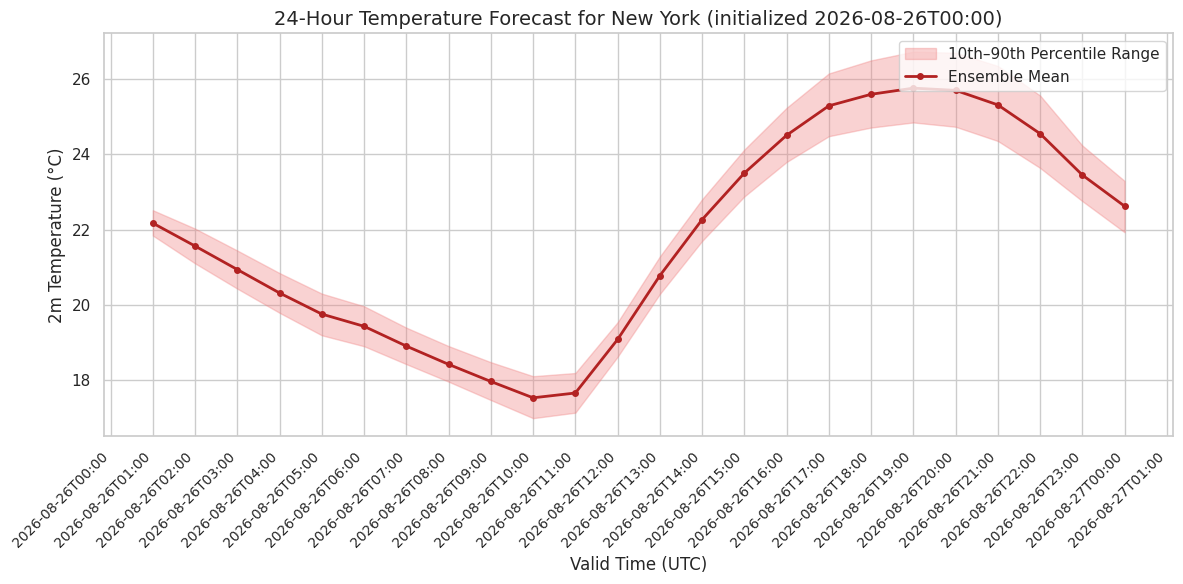

In [ ]:
# Extract the date from the first entry's init_time.
forecast_date = ny_temps['init_time'].iloc[0].strftime('%Y-%m-%dT%H:%M')

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Aggregate across spatial grid cells in NYC polygon if multiple cells exist
ny_temps_agg = ny_temps.groupby('time', as_index=False)[
    ['temperature_2m_mean', 'temperature_2m_p10', 'temperature_2m_p90']
].mean()

# Convert temperature from Kelvin to Celsius
temp_mean_c = ny_temps_agg['temperature_2m_mean'] - 273.15
temp_p10_c = ny_temps_agg['temperature_2m_p10'] - 273.15
temp_p90_c = ny_temps_agg['temperature_2m_p90'] - 273.15
times = ny_temps_agg['time']

# Plot the data
plt.figure(figsize=(12, 6))

# 10th to 90th percentile band
plt.fill_between(
    times,
    temp_p10_c,
    temp_p90_c,
    color='lightcoral',
    alpha=0.35,
    label='10th–90th Percentile Range',
)

# Ensemble mean line
plt.plot(
    times,
    temp_mean_c,
    marker='o',
    markersize=4,
    linestyle='-',
    color='firebrick',
    linewidth=2,
    label='Ensemble Mean',
)

# Labels and axes
plt.xlabel('Valid Time (UTC)', fontsize=12)
plt.ylabel('2m Temperature (°C)', fontsize=12)
plt.title(
    f'24-Hour Temperature Forecast for New York (initialized {forecast_date})',
    fontsize=14,
)
plt.legend(loc='upper right', fontsize=11)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%dT%H:%M')
)
plt.gca().xaxis.set_major_locator(
    mdates.HourLocator(interval=1)
)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

## World - 05/01/2026 00:00 Hours
This query gets the ensemble mean for a variable and displays it onto a map (specifically, with an init time of 2026-04-30 18:00 and valid time of 2026-05-01 00:00).

In contrast to the previous example, we don't calculate the mean over the entire area, and display each pixel on the world map.

In [ ]:
# Map display options
variable = "temperature_2m_mean" # @param ["dewpoint_temperature_2m_mean", "high_cloud_cover_mean", "low_cloud_cover_mean", "mean_sea_level_pressure_mean", "medium_cloud_cover_mean", "sea_surface_temperature_mean", "surface_solar_radiation_downwards_1hr_mean", "temperature_2m_mean", "total_cloud_cover_mean", "total_precipitation_1hr_mean", "total_sky_direct_solar_radiation_at_surface_1hr_mean", "u_component_of_wind_100m_mean", "u_component_of_wind_10m_mean", "v_component_of_wind_100m_mean", "v_component_of_wind_10m_mean", "wind_speed_100m_mean", "wind_speed_10m_mean"]
palette = "coolwarm"  # @param ["coolwarm", "Spectral_r", "BuPu"]
pixelated = True  # @param {type:"boolean"}

world_avgs = (ee.ImageCollection(ee_image_collection)
  .filter(ee.Filter.eq('start_time', '2026-04-30T18:00:00Z'))
  .filter(ee.Filter.eq('end_time', '2026-05-01T00:00:00Z'))
  .select(variable)
  .first())
if (not pixelated):
  world_avgs = world_avgs.resample('bicubic')

min_max = (world_avgs
  .reduceRegion(
      reducer=ee.Reducer.minMax(),
      geometry=ee.Geometry.BBox(-180, -90, 180, 90),  # Global geometry
      scale=world_avgs.projection().nominalScale(),
      maxPixels=1e13
  )
)

vis_params = {
    'bands': [variable],
    'min': min_max.get(f'{variable}_min'),
    'max': min_max.get(f'{variable}_max'),
    'palette': palette,
}

m = geemap.Map(center=[35, 0], zoom=2)
m.add_layer(world_avgs, vis_params, f'{variable} average', True, 0.5)
m


Map(center=[35, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', trans…